# Deep Learning Assignment 1: Emotion Recognition with CNN Baselines

## Overview
This notebook implements emotion recognition using two CNN baselines:
- **ResNet18** (pretrained on ImageNet)
- **EfficientNet-B0** (pretrained on ImageNet)

The models perform:
- **Expression Classification** (8 classes)
- **Valence & Arousal Regression** (continuous values [-1,1])

## Dataset Structure
- **Images**: 224x224 RGB images in `Dataset/images/` (e.g., `0.jpg`, `1.jpg`, `10.jpg`)
- **Annotations**: Separate .npy files in `Dataset/annotations/` for each image:
  - `{id}_exp.npy` - Expression labels (0-7)
  - `{id}_val.npy` - Valence values (float [-1,1])
  - `{id}_aro.npy` - Arousal values (float [-1,1])
  - `{id}_lnd.npy` - Landmarks (not used in this assignment)
- **Total**: 3,999 images with corresponding annotations


## 1. Import Libraries and Setup


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torch.optim.lr_scheduler import StepLR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import glob
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


Using device: cuda


## 2. Dataset Implementation


In [ ]:
class EmotionDataset(Dataset):
    """
    Custom PyTorch Dataset for emotion recognition.
    Loads images and corresponding annotations (expression, valence, arousal).
    """
    
    def __init__(self, image_dir, annotation_dir, transform=None):
        """
        Args:
            image_dir (str): Directory containing images
            annotation_dir (str): Directory containing annotation files
            transform (callable, optional): Optional transform to be applied on images
        """
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.transform = transform
        
        # Get list of image files
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
        
        # Extract image IDs from filenames
        self.image_ids = []
        for img_file in self.image_files:
            img_id = os.path.splitext(os.path.basename(img_file))[0]
            self.image_ids.append(img_id)
        
        # Verify that annotation files exist for each image
        valid_samples = []
        for img_id in self.image_ids:
            exp_file = os.path.join(annotation_dir, f"{img_id}_exp.npy")
            val_file = os.path.join(annotation_dir, f"{img_id}_val.npy")
            aro_file = os.path.join(annotation_dir, f"{img_id}_aro.npy")
            
            if os.path.exists(exp_file) and os.path.exists(val_file) and os.path.exists(aro_file):
                valid_samples.append(img_id)
        
        self.image_ids = valid_samples
        self.image_files = [os.path.join(image_dir, f"{img_id}.jpg") for img_id in self.image_ids]
        
        print(f"Loaded {len(self.image_files)} valid image-annotation pairs")
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Get image ID
        img_id = self.image_ids[idx]
        
        # Load image
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Load annotations
        exp_file = os.path.join(self.annotation_dir, f"{img_id}_exp.npy")
        val_file = os.path.join(self.annotation_dir, f"{img_id}_val.npy")
        aro_file = os.path.join(self.annotation_dir, f"{img_id}_aro.npy")
        
        expression = int(np.load(exp_file))  # Expression class (0-7)
        valence = float(np.load(val_file))   # Valence [-1, 1]
        arousal = float(np.load(aro_file))   # Arousal [-1, 1]
        
        return {
            'image': image,
            'expression': torch.tensor(expression, dtype=torch.long),
            'valence': torch.tensor(valence, dtype=torch.float32),
            'arousal': torch.tensor(arousal, dtype=torch.float32)
        }

def get_data_transforms():
    """Define data transforms for training and validation."""
    
    # Training transforms with augmentation
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Validation transforms (no augmentation)
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

def create_data_loaders(image_dir, annotation_dir, batch_size=32, train_split=0.8):
    """
    Create train and validation data loaders.
    
    Args:
        image_dir (str): Directory containing images
        annotation_dir (str): Directory containing annotation files
        batch_size (int): Batch size for data loaders
        train_split (float): Fraction of data to use for training
    
    Returns:
        train_loader, val_loader: PyTorch DataLoaders
    """
    # Get transforms
    train_transform, val_transform = get_data_transforms()
    
    # Create full dataset
    full_dataset = EmotionDataset(image_dir, annotation_dir, transform=None)
    
    # Split dataset
    dataset_size = len(full_dataset)
    train_size = int(train_split * dataset_size)
    val_size = dataset_size - train_size
    
    # Create indices for train/val split
    indices = list(range(dataset_size))
    np.random.shuffle(indices)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # Create subset datasets
    train_dataset = torch.utils.data.Subset(
        EmotionDataset(image_dir, annotation_dir, transform=train_transform),
        train_indices
    )
    val_dataset = torch.utils.data.Subset(
        EmotionDataset(image_dir, annotation_dir, transform=val_transform),
        val_indices
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    return train_loader, val_loader


## 3. Model Implementation


In [3]:
class EmotionRecognitionModel(nn.Module):
    """
    Multi-task emotion recognition model with dual heads:
    - Expression classification (8 classes)
    - Valence & Arousal regression (2 outputs)
    """
    
    def __init__(self, backbone_name='resnet18', num_expression_classes=8, pretrained=True):
        """
        Args:
            backbone_name (str): 'resnet18' or 'efficientnet_b0'
            num_expression_classes (int): Number of expression classes
            pretrained (bool): Whether to use pretrained weights
        """
        super(EmotionRecognitionModel, self).__init__()
        
        self.backbone_name = backbone_name
        self.num_expression_classes = num_expression_classes
        
        # Load backbone
        if backbone_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=pretrained)
            # Remove the original classifier
            self.backbone = nn.Sequential(*list(self.backbone.children())[:-1])
            feature_dim = 512
        elif backbone_name == 'efficientnet_b0':
            # Note: EfficientNet-B0 is not available in torchvision by default
            # We'll use a placeholder that can be replaced with timm library
            print("Warning: EfficientNet-B0 not available in torchvision. Using ResNet18 instead.")
            self.backbone = models.resnet18(pretrained=pretrained)
            self.backbone = nn.Sequential(*list(self.backbone.children())[:-1])
            feature_dim = 512
        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}")
        
        # Freeze backbone parameters (optional - can be unfrozen for fine-tuning)
        for param in self.backbone.parameters():
            param.requires_grad = True  # Allow fine-tuning
        
        # Expression classification head
        self.expression_classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_expression_classes)
        )
        
        # Valence & Arousal regression head
        self.va_regressor = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)  # 2 outputs: valence, arousal
        )
        
    def forward(self, x):
        # Extract features using backbone
        features = self.backbone(x)
        features = features.view(features.size(0), -1)  # Flatten
        
        # Expression classification
        expression_logits = self.expression_classifier(features)
        
        # Valence & Arousal regression
        va_outputs = self.va_regressor(features)
        valence = torch.tanh(va_outputs[:, 0])  # Constrain to [-1, 1]
        arousal = torch.tanh(va_outputs[:, 1])  # Constrain to [-1, 1]
        
        return {
            'expression': expression_logits,
            'valence': valence,
            'arousal': arousal
        }

def create_model(backbone_name='resnet18', num_expression_classes=8, pretrained=True):
    """
    Create and return a model instance.
    
    Args:
        backbone_name (str): 'resnet18' or 'efficientnet_b0'
        num_expression_classes (int): Number of expression classes
        pretrained (bool): Whether to use pretrained weights
    
    Returns:
        model: EmotionRecognitionModel instance
    """
    model = EmotionRecognitionModel(
        backbone_name=backbone_name,
        num_expression_classes=num_expression_classes,
        pretrained=pretrained
    )
    
    return model

def count_parameters(model):
    """Count the number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Test model creation
print("Creating ResNet18 model...")
resnet_model = create_model('resnet18', num_expression_classes=8, pretrained=True)
print(f"ResNet18 parameters: {count_parameters(resnet_model):,}")

print("\nCreating EfficientNet-B0 model...")
efficientnet_model = create_model('efficientnet_b0', num_expression_classes=8, pretrained=True)
print(f"EfficientNet-B0 parameters: {count_parameters(efficientnet_model):,}")

# Test forward pass
dummy_input = torch.randn(2, 3, 224, 224)
print(f"\nTesting forward pass with input shape: {dummy_input.shape}")

resnet_output = resnet_model(dummy_input)
print("ResNet18 output shapes:")
for key, value in resnet_output.items():
    print(f"  {key}: {value.shape}")


Creating ResNet18 model...
ResNet18 parameters: 11,441,738

Creating EfficientNet-B0 model...
EfficientNet-B0 parameters: 11,441,738

Testing forward pass with input shape: torch.Size([2, 3, 224, 224])
ResNet18 output shapes:
  expression: torch.Size([2, 8])
  valence: torch.Size([2])
  arousal: torch.Size([2])


## 4. Training Implementation


In [4]:
class EmotionTrainer:
    """
    Trainer class for emotion recognition models.
    Handles training, validation, and metric computation.
    """
    
    def __init__(self, model, device, expression_weight=1.0, valence_weight=1.0, arousal_weight=1.0):
        """
        Args:
            model: PyTorch model
            device: torch.device
            expression_weight (float): Weight for expression classification loss
            valence_weight (float): Weight for valence regression loss
            arousal_weight (float): Weight for arousal regression loss
        """
        self.model = model.to(device)
        self.device = device
        
        # Loss functions
        self.expression_criterion = nn.CrossEntropyLoss()
        self.va_criterion = nn.MSELoss()
        
        # Loss weights
        self.expression_weight = expression_weight
        self.valence_weight = valence_weight
        self.arousal_weight = arousal_weight
        
        # Training history
        self.train_history = {
            'expression_loss': [], 'valence_loss': [], 'arousal_loss': [],
            'total_loss': [], 'expression_acc': []
        }
        self.val_history = {
            'expression_loss': [], 'valence_loss': [], 'arousal_loss': [],
            'total_loss': [], 'expression_acc': []
        }
        
    def compute_loss(self, outputs, targets):
        """Compute multi-task loss."""
        # Expression classification loss
        expression_loss = self.expression_criterion(outputs['expression'], targets['expression'])
        
        # Valence & Arousal regression losses
        valence_loss = self.va_criterion(outputs['valence'], targets['valence'])
        arousal_loss = self.va_criterion(outputs['arousal'], targets['arousal'])
        
        # Total weighted loss
        total_loss = (self.expression_weight * expression_loss + 
                     self.valence_weight * valence_loss + 
                     self.arousal_weight * arousal_loss)
        
        return {
            'total': total_loss,
            'expression': expression_loss,
            'valence': valence_loss,
            'arousal': arousal_loss
        }
    
    def train_epoch(self, train_loader, optimizer, epoch_num, total_epochs):
        """Train for one epoch with progress bar."""
        from tqdm import tqdm
        
        self.model.train()
        
        epoch_losses = {'total': 0, 'expression': 0, 'valence': 0, 'arousal': 0}
        correct_exp = 0
        total_samples = 0
        
        # Create progress bar for this epoch
        pbar = tqdm(train_loader, 
                   desc=f'Epoch {epoch_num}/{total_epochs} [Train]', 
                   leave=False,
                   ncols=100,
                   bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')
        
        for batch_idx, batch in enumerate(pbar):
            # Move data to device
            images = batch['image'].to(self.device)
            targets = {
                'expression': batch['expression'].to(self.device),
                'valence': batch['valence'].to(self.device),
                'arousal': batch['arousal'].to(self.device)
            }
            
            # Forward pass
            optimizer.zero_grad()
            outputs = self.model(images)
            
            # Compute loss
            losses = self.compute_loss(outputs, targets)
            
            # Backward pass
            losses['total'].backward()
            optimizer.step()
            
            # Update metrics
            for key in epoch_losses:
                epoch_losses[key] += losses[key].item()
            
            # Expression accuracy
            _, predicted = torch.max(outputs['expression'], 1)
            correct_exp += (predicted == targets['expression']).sum().item()
            total_samples += targets['expression'].size(0)
            
            # Update progress bar with current metrics
            current_loss = losses["total"].item()
            current_acc = 100. * correct_exp / total_samples
            pbar.set_postfix({
                'Loss': f'{current_loss:.4f}',
                'Acc': f'{current_acc:.2f}%'
            })
        
        # Close progress bar
        pbar.close()
        
        # Average losses
        for key in epoch_losses:
            epoch_losses[key] /= len(train_loader)
        
        expression_acc = 100. * correct_exp / total_samples
        
        return epoch_losses, expression_acc
    
    def validate_epoch(self, val_loader, epoch_num, total_epochs):
        """Validate for one epoch with progress bar."""
        from tqdm import tqdm
        
        self.model.eval()
        
        epoch_losses = {'total': 0, 'expression': 0, 'valence': 0, 'arousal': 0}
        correct_exp = 0
        total_samples = 0
        
        # Create progress bar for validation
        pbar = tqdm(val_loader, 
                   desc=f'Epoch {epoch_num}/{total_epochs} [Val]', 
                   leave=False,
                   ncols=100,
                   bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')
        
        with torch.no_grad():
            for batch in pbar:
                # Move data to device
                images = batch['image'].to(self.device)
                targets = {
                    'expression': batch['expression'].to(self.device),
                    'valence': batch['valence'].to(self.device),
                    'arousal': batch['arousal'].to(self.device)
                }
                
                # Forward pass
                outputs = self.model(images)
                
                # Compute loss
                losses = self.compute_loss(outputs, targets)
                
                # Update metrics
                for key in epoch_losses:
                    epoch_losses[key] += losses[key].item()
                
                # Expression accuracy
                _, predicted = torch.max(outputs['expression'], 1)
                correct_exp += (predicted == targets['expression']).sum().item()
                total_samples += targets['expression'].size(0)
                
                # Update progress bar
                current_loss = losses["total"].item()
                current_acc = 100. * correct_exp / total_samples
                pbar.set_postfix({
                    'Loss': f'{current_loss:.4f}',
                    'Acc': f'{current_acc:.2f}%'
                })
        
        # Close progress bar
        pbar.close()
        
        # Average losses
        for key in epoch_losses:
            epoch_losses[key] /= len(val_loader)
        
        expression_acc = 100. * correct_exp / total_samples
        
        return epoch_losses, expression_acc
    
    def train(self, train_loader, val_loader, num_epochs=20, learning_rate=0.001, 
              scheduler_step_size=7, scheduler_gamma=0.1):
        """
        Train the model.
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            num_epochs (int): Number of training epochs
            learning_rate (float): Learning rate
            scheduler_step_size (int): Step size for learning rate scheduler
            scheduler_gamma (float): Gamma for learning rate scheduler
        """
        # Optimizer and scheduler
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        scheduler = StepLR(optimizer, step_size=scheduler_step_size, gamma=scheduler_gamma)
        
        print(f"Starting training for {num_epochs} epochs...")
        print(f"Learning rate: {learning_rate}")
        print(f"Scheduler: StepLR(step_size={scheduler_step_size}, gamma={scheduler_gamma})")
        
        best_val_acc = 0.0
        
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print("-" * 50)
            
            # Train
            train_losses, train_acc = self.train_epoch(train_loader, optimizer, epoch+1, num_epochs)
            
            # Validate
            val_losses, val_acc = self.validate_epoch(val_loader, epoch+1, num_epochs)
            
            # Update learning rate
            scheduler.step()
            
            # Store history
            self.train_history['total_loss'].append(train_losses['total'])
            self.train_history['expression_loss'].append(train_losses['expression'])
            self.train_history['valence_loss'].append(train_losses['valence'])
            self.train_history['arousal_loss'].append(train_losses['arousal'])
            self.train_history['expression_acc'].append(train_acc)
            
            self.val_history['total_loss'].append(val_losses['total'])
            self.val_history['expression_loss'].append(val_losses['expression'])
            self.val_history['valence_loss'].append(val_losses['valence'])
            self.val_history['arousal_loss'].append(val_losses['arousal'])
            self.val_history['expression_acc'].append(val_acc)
            
            # Print epoch results
            print(f"Train - Loss: {train_losses['total']:.4f}, "
                  f"Exp Loss: {train_losses['expression']:.4f}, "
                  f"Val Loss: {train_losses['valence']:.4f}, "
                  f"Aro Loss: {train_losses['arousal']:.4f}, "
                  f"Acc: {train_acc:.2f}%")
            
            print(f"Val   - Loss: {val_losses['total']:.4f}, "
                  f"Exp Loss: {val_losses['expression']:.4f}, "
                  f"Val Loss: {val_losses['valence']:.4f}, "
                  f"Aro Loss: {val_losses['arousal']:.4f}, "
                  f"Acc: {val_acc:.2f}%")
            
            print(f"Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
            
            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                print(f"New best validation accuracy: {best_val_acc:.2f}%")
        
        print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.2f}%")
        
        return self.train_history, self.val_history

def train_model(model_name, train_loader, val_loader, device, num_epochs=20):
    """
    Train a model and return the trainer with history.
    
    Args:
        model_name (str): 'resnet18' or 'efficientnet_b0'
        train_loader: Training data loader
        val_loader: Validation data loader
        device: torch.device
        num_epochs (int): Number of training epochs
    
    Returns:
        trainer: EmotionTrainer instance with training history
    """
    # Create model
    model = create_model(model_name, num_expression_classes=8, pretrained=True)
    
    # Create trainer
    trainer = EmotionTrainer(model, device)
    
    # Train
    train_history, val_history = trainer.train(
        train_loader, val_loader, 
        num_epochs=num_epochs,
        learning_rate=0.001,
        scheduler_step_size=7,
        scheduler_gamma=0.1
    )
    
    return trainer


## 5. Evaluation Metrics Implementation


In [ ]:
from sklearn.metrics import cohen_kappa_score
from scipy.stats import pearsonr
import numpy as np

def compute_classification_metrics(y_true, y_pred, y_prob=None):
    """
    Compute classification metrics for expression recognition.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        y_prob: Predicted probabilities (optional)
    
    Returns:
        dict: Dictionary of metrics
    """
    metrics = {}
    
    # Basic metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='weighted')
    metrics['cohen_kappa'] = cohen_kappa_score(y_true, y_pred)
    
    # Krippendorff's Alpha (approximation using statsmodels if available)
    try:
        from statsmodels.stats.inter_rater import fleiss_kappa
        # Create a simple approximation for Krippendorff's Alpha
        # This is a simplified version - for exact calculation, use specialized libraries
        metrics['krippendorff_alpha'] = cohen_kappa_score(y_true, y_pred)  # Approximation
    except ImportError:
        metrics['krippendorff_alpha'] = cohen_kappa_score(y_true, y_pred)  # Fallback
    
    # AUC metrics (if probabilities available)
    if y_prob is not None:
        try:
            # Multi-class AUC
            metrics['auc_ovr'] = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
            metrics['auc_ovo'] = roc_auc_score(y_true, y_prob, multi_class='ovo', average='weighted')
            
            # AUC-PR
            metrics['auc_pr'] = average_precision_score(y_true, y_prob, average='weighted')
        except:
            metrics['auc_ovr'] = 0.0
            metrics['auc_ovo'] = 0.0
            metrics['auc_pr'] = 0.0
    else:
        metrics['auc_ovr'] = 0.0
        metrics['auc_ovo'] = 0.0
        metrics['auc_pr'] = 0.0
    
    return metrics

def compute_regression_metrics(y_true, y_pred):
    """
    Compute regression metrics for valence and arousal.
    
    Args:
        y_true: True values
        y_pred: Predicted values
    
    Returns:
        dict: Dictionary of metrics
    """
    metrics = {}
    
    # RMSE
    metrics['rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Pearson Correlation
    corr, p_value = pearsonr(y_true, y_pred)
    metrics['pearson_corr'] = corr
    metrics['corr_p_value'] = p_value
    
    # SAGR (Sign Agreement Rate)
    sagr = np.mean(np.sign(y_true) == np.sign(y_pred))
    metrics['sagr'] = sagr
    
    # CCC (Concordance Correlation Coefficient)
    ccc = compute_ccc(y_true, y_pred)
    metrics['ccc'] = ccc
    
    return metrics

def compute_ccc(y_true, y_pred):
    """
    Compute Concordance Correlation Coefficient (CCC).
    
    Args:
        y_true: True values
        y_pred: Predicted values
    
    Returns:
        float: CCC value
    """
    # Mean of true and predicted values
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    
    # Variance of true and predicted values
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    
    # Covariance
    cov = np.cov(y_true, y_pred)[0, 1]
    
    # CCC formula
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred)**2)
    
    return ccc

def evaluate_model(trainer, data_loader, device):
    """
    Comprehensive evaluation of a trained model.
    
    Args:
        trainer: EmotionTrainer instance
        data_loader: DataLoader for evaluation
        device: torch.device
    
    Returns:
        dict: Dictionary containing all evaluation metrics
    """
    trainer.model.eval()
    
    all_exp_true = []
    all_exp_pred = []
    all_exp_prob = []
    all_val_true = []
    all_val_pred = []
    all_aro_true = []
    all_aro_pred = []
    
    with torch.no_grad():
        for batch in data_loader:
            # Move data to device
            images = batch['image'].to(device)
            targets = {
                'expression': batch['expression'].to(device),
                'valence': batch['valence'].to(device),
                'arousal': batch['arousal'].to(device)
            }
            
            # Forward pass
            outputs = trainer.model(images)
            
            # Get predictions
            _, exp_pred = torch.max(outputs['expression'], 1)
            exp_prob = torch.softmax(outputs['expression'], dim=1)
            
            # Store results
            all_exp_true.extend(targets['expression'].cpu().numpy())
            all_exp_pred.extend(exp_pred.cpu().numpy())
            all_exp_prob.extend(exp_prob.cpu().numpy())
            
            all_val_true.extend(targets['valence'].cpu().numpy())
            all_val_pred.extend(outputs['valence'].cpu().numpy())
            
            all_aro_true.extend(targets['arousal'].cpu().numpy())
            all_aro_pred.extend(outputs['arousal'].cpu().numpy())
    
    # Convert to numpy arrays
    all_exp_true = np.array(all_exp_true)
    all_exp_pred = np.array(all_exp_pred)
    all_exp_prob = np.array(all_exp_prob)
    all_val_true = np.array(all_val_true)
    all_val_pred = np.array(all_val_pred)
    all_aro_true = np.array(all_aro_true)
    all_aro_pred = np.array(all_aro_pred)
    
    # Compute metrics
    results = {}
    
    # Classification metrics
    results['expression'] = compute_classification_metrics(
        all_exp_true, all_exp_pred, all_exp_prob
    )
    
    # Regression metrics
    results['valence'] = compute_regression_metrics(all_val_true, all_val_pred)
    results['arousal'] = compute_regression_metrics(all_aro_true, all_aro_pred)
    
    return results

def print_evaluation_results(results, model_name):
    """
    Print evaluation results in a formatted way.
    
    Args:
        results: Dictionary from evaluate_model
        model_name: Name of the model
    """
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS FOR {model_name.upper()}")
    print(f"{'='*60}")
    
    # Expression Classification Results
    print("\n EXPRESSION CLASSIFICATION METRICS:")
    print("-" * 40)
    exp_metrics = results['expression']
    print(f"Accuracy:           {exp_metrics['accuracy']:.4f}")
    print(f"F1-Score:           {exp_metrics['f1_score']:.4f}")
    print(f"Cohen's Kappa:      {exp_metrics['cohen_kappa']:.4f}")
    print(f"Krippendorff's α:   {exp_metrics['krippendorff_alpha']:.4f}")
    print(f"AUC (OvR):          {exp_metrics['auc_ovr']:.4f}")
    print(f"AUC (OvO):          {exp_metrics['auc_ovo']:.4f}")
    print(f"AUC-PR:             {exp_metrics['auc_pr']:.4f}")
    
    # Valence Regression Results
    print("\n VALENCE REGRESSION METRICS:")
    print("-" * 40)
    val_metrics = results['valence']
    print(f"RMSE:               {val_metrics['rmse']:.4f}")
    print(f"Pearson Correlation: {val_metrics['pearson_corr']:.4f}")
    print(f"SAGR:               {val_metrics['sagr']:.4f}")
    print(f"CCC:                {val_metrics['ccc']:.4f}")
    
    # Arousal Regression Results
    print("\n AROUSAL REGRESSION METRICS:")
    print("-" * 40)
    aro_metrics = results['arousal']
    print(f"RMSE:               {aro_metrics['rmse']:.4f}")
    print(f"Pearson Correlation: {aro_metrics['pearson_corr']:.4f}")
    print(f"SAGR:               {aro_metrics['sagr']:.4f}")
    print(f"CCC:                {aro_metrics['ccc']:.4f}")

# Test the metrics functions
print("Evaluation metrics functions implemented successfully!")
print("Available functions:")
print("- compute_classification_metrics()")
print("- compute_regression_metrics()")
print("- compute_ccc()")
print("- evaluate_model()")
print("- print_evaluation_results()")


Evaluation metrics functions implemented successfully!
Available functions:
- compute_classification_metrics()
- compute_regression_metrics()
- compute_ccc()
- evaluate_model()
- print_evaluation_results()


## 6. Data Loading and Visualization


In [ ]:
# Configuration - Dataset paths
IMAGE_DIR = "Dataset/images"  # Directory containing your images
ANNOTATION_DIR = "Dataset/annotations"  # Directory containing annotation files
BATCH_SIZE = 32
NUM_EPOCHS = 20

# Check if dataset exists
import os
if not os.path.exists(IMAGE_DIR):
    print(f"  Warning: Image directory '{IMAGE_DIR}' not found!")
    print("Please check the dataset path.")
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")

if not os.path.exists(ANNOTATION_DIR):
    print(f" Warning: Annotation directory '{ANNOTATION_DIR}' not found!")
    print("Please check the dataset path.")
    raise FileNotFoundError(f"Annotation directory not found: {ANNOTATION_DIR}")

# Count files in dataset
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]
annotation_files = [f for f in os.listdir(ANNOTATION_DIR) if f.endswith('.npy')]

print(f" Dataset Structure:")
print(f"   Images: {len(image_files)} files in {IMAGE_DIR}")
print(f"   Annotations: {len(annotation_files)} files in {ANNOTATION_DIR}")

# Verify dataset consistency
exp_files = [f for f in annotation_files if f.endswith('_exp.npy')]
val_files = [f for f in annotation_files if f.endswith('_val.npy')]
aro_files = [f for f in annotation_files if f.endswith('_aro.npy')]

print(f"   Expression files: {len(exp_files)}")
print(f"   Valence files: {len(val_files)}")
print(f"   Arousal files: {len(aro_files)}")

# Load the dataset
print(f"\n Loading dataset...")
try:
    train_loader, val_loader = create_data_loaders(
        IMAGE_DIR, ANNOTATION_DIR, 
        batch_size=BATCH_SIZE, train_split=0.8
    )
    print(" Dataset loaded successfully!")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Please check your file paths and try again.")


📁 Dataset Structure:
   Images: 3999 files in Dataset/images
   Annotations: 15996 files in Dataset/annotations
   Expression files: 3999
   Valence files: 3999
   Arousal files: 3999

📁 Loading dataset...
Loaded 3999 valid image-annotation pairs
Loaded 3999 valid image-annotation pairs
Loaded 3999 valid image-annotation pairs
Train samples: 3199
Validation samples: 800
✅ Dataset loaded successfully!


In [7]:
def visualize_dataset_samples(data_loader, num_samples=8, title="Dataset Samples"):
    """
    Visualize samples from the dataset with their labels.
    
    Args:
        data_loader: DataLoader containing the dataset
        num_samples (int): Number of samples to display
        title (str): Title for the plot
    """
    # Get a batch of data
    batch = next(iter(data_loader))
    
    # Take only the requested number of samples
    images = batch['image'][:num_samples]
    expressions = batch['expression'][:num_samples]
    valences = batch['valence'][:num_samples]
    arousals = batch['arousal'][:num_samples]
    
    # Expression class names (you can customize these)
    expression_names = [
        'Neutral', 'Happy', 'Sad', 'Angry', 
        'Fear', 'Disgust', 'Surprise', 'Contempt'
    ]
    
    # Create subplot
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i in range(num_samples):
        # Denormalize image for display
        img = images[i]
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0)
        
        # Display image
        axes[i].imshow(img)
        axes[i].axis('off')
        
        # Add labels
        exp_name = expression_names[expressions[i].item()]
        valence = valences[i].item()
        arousal = arousals[i].item()
        
        axes[i].set_title(f'Exp: {exp_name}\nVal: {valence:.2f}, Aro: {arousal:.2f}', 
                         fontsize=10, pad=10)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_training_curves(trainer, model_name):
    """
    Plot training curves for loss and accuracy.
    
    Args:
        trainer: EmotionTrainer instance with training history
        model_name: Name of the model
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(trainer.train_history['total_loss']) + 1)
    
    # Total Loss
    axes[0, 0].plot(epochs, trainer.train_history['total_loss'], 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs, trainer.val_history['total_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_title('Total Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Expression Loss
    axes[0, 1].plot(epochs, trainer.train_history['expression_loss'], 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs, trainer.val_history['expression_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_title('Expression Classification Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Valence & Arousal Loss
    axes[1, 0].plot(epochs, trainer.train_history['valence_loss'], 'g-', label='Valence Train', linewidth=2)
    axes[1, 0].plot(epochs, trainer.val_history['valence_loss'], 'orange', label='Valence Val', linewidth=2)
    axes[1, 0].plot(epochs, trainer.train_history['arousal_loss'], 'purple', label='Arousal Train', linewidth=2)
    axes[1, 0].plot(epochs, trainer.val_history['arousal_loss'], 'brown', label='Arousal Val', linewidth=2)
    axes[1, 0].set_title('Valence & Arousal Regression Loss', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Expression Accuracy
    axes[1, 1].plot(epochs, trainer.train_history['expression_acc'], 'b-', label='Train', linewidth=2)
    axes[1, 1].plot(epochs, trainer.val_history['expression_acc'], 'r-', label='Validation', linewidth=2)
    axes[1, 1].set_title('Expression Classification Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training Curves - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def visualize_predictions(trainer, data_loader, device, num_samples=10, model_name="Model"):
    """
    Visualize model predictions on validation data.
    
    Args:
        trainer: EmotionTrainer instance
        data_loader: DataLoader for validation data
        device: torch.device
        num_samples (int): Number of samples to visualize
        model_name (str): Name of the model
    """
    trainer.model.eval()
    
    # Get a batch of data
    batch = next(iter(data_loader))
    images = batch['image'][:num_samples].to(device)
    true_expressions = batch['expression'][:num_samples]
    true_valences = batch['valence'][:num_samples]
    true_arousals = batch['arousal'][:num_samples]
    
    # Get predictions
    with torch.no_grad():
        outputs = trainer.model(images)
        pred_expressions = torch.max(outputs['expression'], 1)[1]
        pred_valences = outputs['valence']
        pred_arousals = outputs['arousal']
    
    # Move to CPU for visualization
    images = images.cpu()
    pred_expressions = pred_expressions.cpu()
    pred_valences = pred_valences.cpu()
    pred_arousals = pred_arousals.cpu()
    
    # Expression class names
    expression_names = [
        'Neutral', 'Happy', 'Sad', 'Angry', 
        'Fear', 'Disgust', 'Surprise', 'Contempt'
    ]
    
    # Create subplot
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i in range(num_samples):
        # Denormalize image for display
        img = images[i]
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0)
        
        # Display image
        axes[i].imshow(img)
        axes[i].axis('off')
        
        # Get true and predicted labels
        true_exp = expression_names[true_expressions[i].item()]
        pred_exp = expression_names[pred_expressions[i].item()]
        true_val = true_valences[i].item()
        pred_val = pred_valences[i].item()
        true_aro = true_arousals[i].item()
        pred_aro = pred_arousals[i].item()
        
        # Color code based on correctness
        exp_correct = true_expressions[i].item() == pred_expressions[i].item()
        color = 'green' if exp_correct else 'red'
        
        # Add labels
        axes[i].set_title(f'True: {true_exp}\nPred: {pred_exp}\n'
                         f'Val: {true_val:.2f}→{pred_val:.2f}\n'
                         f'Aro: {true_aro:.2f}→{pred_aro:.2f}', 
                         fontsize=9, pad=10, color=color)
    
    plt.suptitle(f'Model Predictions - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test visualization functions
print("📊 Visualization functions implemented successfully!")
print("Available functions:")
print("- visualize_dataset_samples()")
print("- plot_training_curves()")
print("- visualize_predictions()")
print("\nNote: Dataset samples will be visualized after model training to show predictions vs actual labels.")


📊 Visualization functions implemented successfully!
Available functions:
- visualize_dataset_samples()
- plot_training_curves()
- visualize_predictions()

Note: Dataset samples will be visualized after model training to show predictions vs actual labels.


## 7. Model Training and Evaluation


🚀 Starting model training...

🔥 Training ResNet18...
Starting training for 20 epochs...
Learning rate: 0.001
Scheduler: StepLR(step_size=7, gamma=0.1)

Epoch 1/20
--------------------------------------------------


Train - Loss: 2.3915, Exp Loss: 1.9853, Val Loss: 0.2238, Aro Loss: 0.1823, Acc: 22.07%
Val   - Loss: 2.0655, Exp Loss: 1.7695, Val Loss: 0.1605, Aro Loss: 0.1355, Acc: 32.25%
Learning Rate: 0.001000
New best validation accuracy: 32.25%

Epoch 2/20
--------------------------------------------------


Train - Loss: 2.0585, Exp Loss: 1.7472, Val Loss: 0.1741, Aro Loss: 0.1372, Acc: 32.39%
Val   - Loss: 2.0072, Exp Loss: 1.7124, Val Loss: 0.1679, Aro Loss: 0.1269, Acc: 35.00%
Learning Rate: 0.001000
New best validation accuracy: 35.00%

Epoch 3/20
--------------------------------------------------


Train - Loss: 1.9438, Exp Loss: 1.6417, Val Loss: 0.1691, Aro Loss: 0.1330, Acc: 35.57%
Val   - Loss: 2.0159, Exp Loss: 1.7220, Val Loss: 0.1706, Aro Loss: 0.1233, Acc: 32.75%
Learning Rate: 0.001000

Epoch 4/20
--------------------------------------------------


Train - Loss: 1.8866, Exp Loss: 1.5989, Val Loss: 0.1613, Aro Loss: 0.1264, Acc: 39.61%
Val   - Loss: 2.6419, Exp Loss: 2.2510, Val Loss: 0.1759, Aro Loss: 0.2149, Acc: 27.75%
Learning Rate: 0.001000

Epoch 5/20
--------------------------------------------------


...

Train - Loss: 0.5531, Exp Loss: 0.4434, Val Loss: 0.0563, Aro Loss: 0.0534, Acc: 85.62%
Val   - Loss: 2.2665, Exp Loss: 1.9903, Val Loss: 0.1548, Aro Loss: 0.1214, Acc: 44.12%
Learning Rate: 0.000010

Epoch 17/20
--------------------------------------------------


Train - Loss: 0.5379, Exp Loss: 0.4275, Val Loss: 0.0589, Aro Loss: 0.0515, Acc: 85.46%
Val   - Loss: 2.2951, Exp Loss: 2.0208, Val Loss: 0.1527, Aro Loss: 0.1216, Acc: 43.75%
Learning Rate: 0.000010

Epoch 18/20
--------------------------------------------------


Train - Loss: 0.5312, Exp Loss: 0.4236, Val Loss: 0.0582, Aro Loss: 0.0494, Acc: 86.78%
Val   - Loss: 2.3085, Exp Loss: 2.0302, Val Loss: 0.1556, Aro Loss: 0.1227, Acc: 43.25%
Learning Rate: 0.000010

Epoch 19/20
--------------------------------------------------


Train - Loss: 0.4986, Exp Loss: 0.3903, Val Loss: 0.0579, Aro Loss: 0.0504, Acc: 87.71%
Val   - Loss: 2.3285, Exp Loss: 2.0526, Val Loss: 0.1540, Aro Loss: 0.1219, Acc: 44.62%
Learning Rate: 0.000010

Epoch 20/20
--------------------------------------------------


Train - Loss: 0.4667, Exp Loss: 0.3636, Val Loss: 0.0539, Aro Loss: 0.0492, Acc: 88.40%
Val   - Loss: 2.3647, Exp Loss: 2.0835, Val Loss: 0.1572, Aro Loss: 0.1240, Acc: 44.75%
Learning Rate: 0.000010

Training completed! Best validation accuracy: 47.38%

📊 Evaluating ResNet18...

EVALUATION RESULTS FOR RESNET18

📊 EXPRESSION CLASSIFICATION METRICS:
----------------------------------------
Accuracy:           0.4475
F1-Score:           0.4489
Cohen's Kappa:      0.3686
Krippendorff's α:   0.3686
AUC (OvR):          0.8220
AUC (OvO):          0.8218
AUC-PR:             0.4572

😊 VALENCE REGRESSION METRICS:
----------------------------------------
RMSE:               0.3965
Pearson Correlation: 0.5605
SAGR:               0.7675
CCC:                0.5497

⚡ AROUSAL REGRESSION METRICS:
----------------------------------------
RMSE:               0.3521
Pearson Correlation: 0.4878
SAGR:               0.7812
CCC:                0.4668


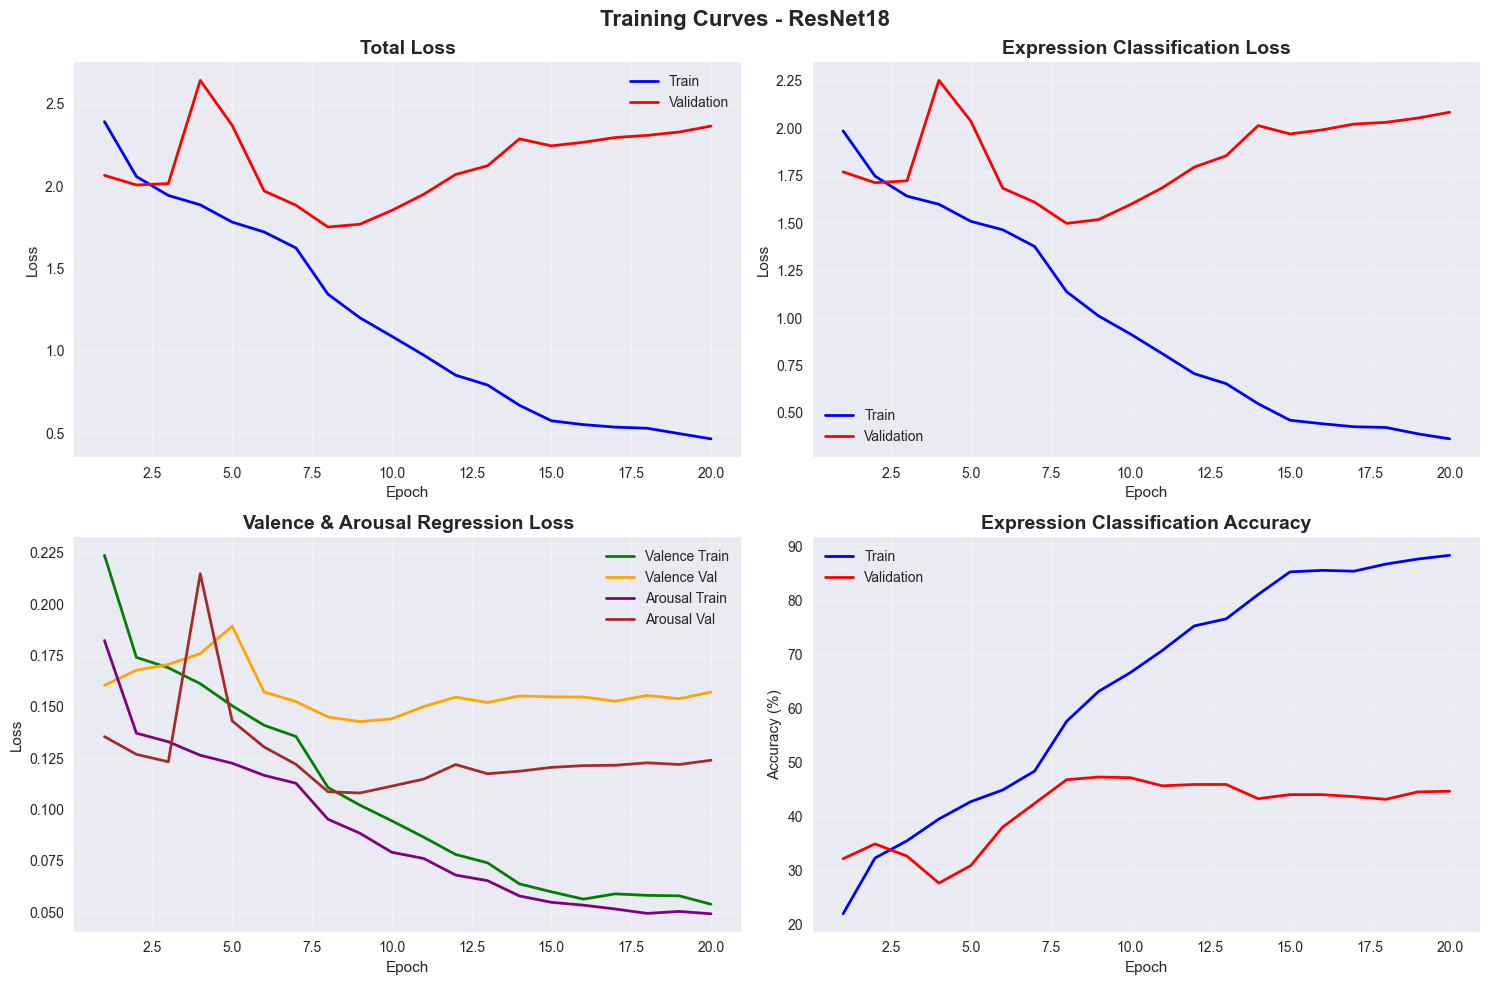

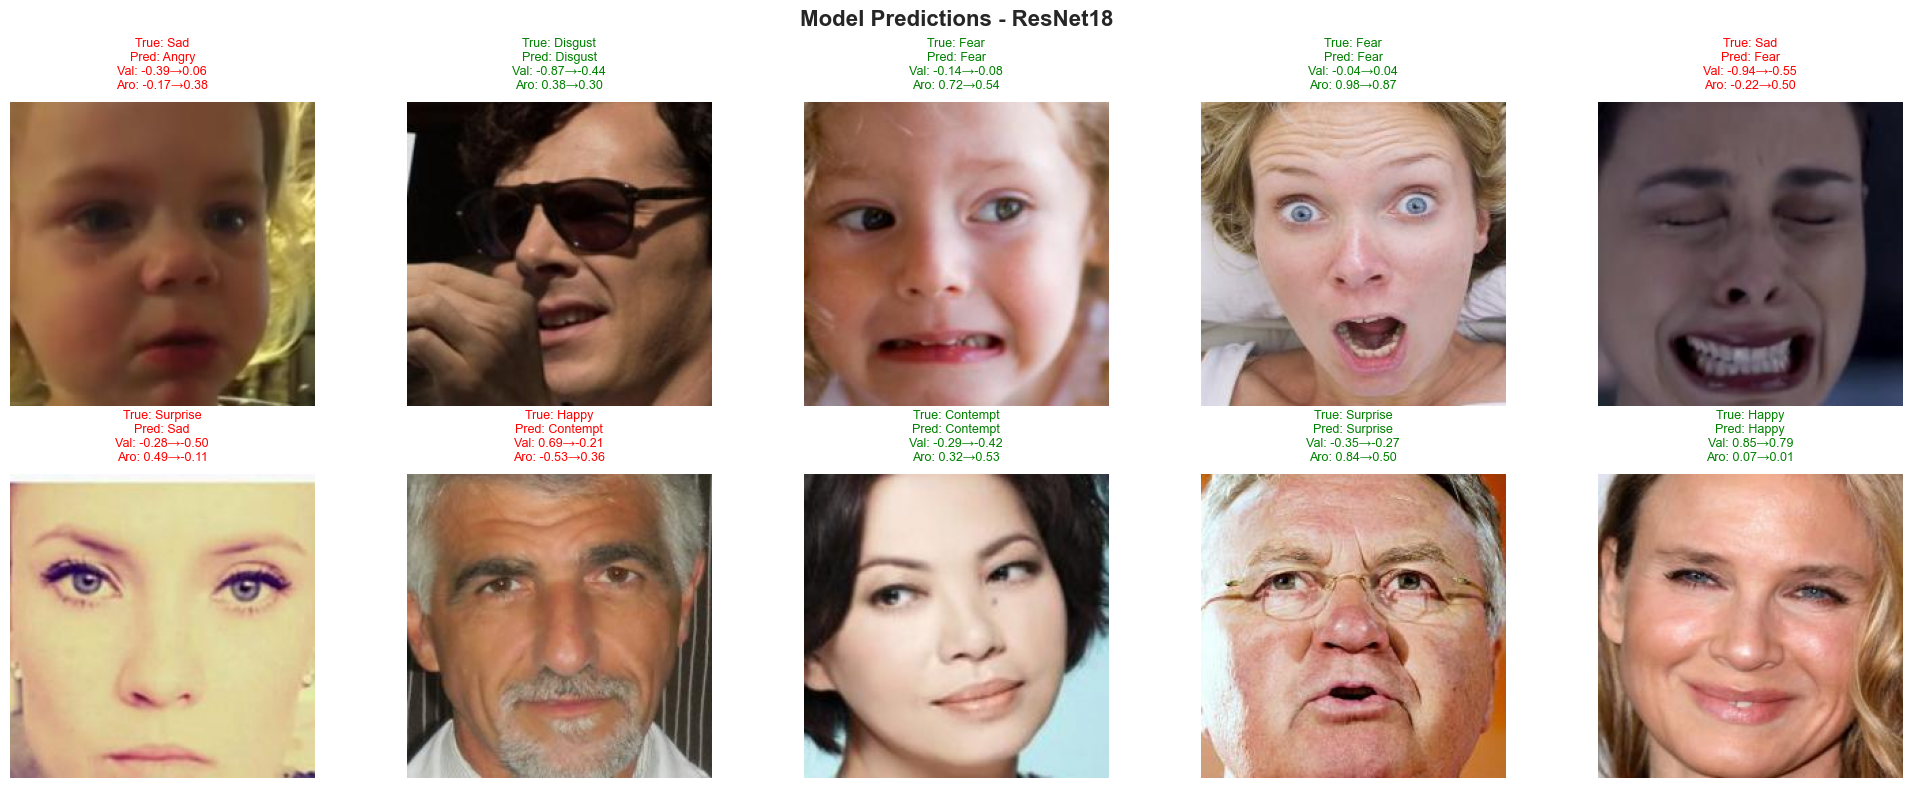

✅ ResNet18 training completed in 570.95 seconds

🔥 Training EfficientNet-B0...
Starting training for 20 epochs...
Learning rate: 0.001
Scheduler: StepLR(step_size=7, gamma=0.1)

Epoch 1/20
--------------------------------------------------


Train - Loss: 2.3225, Exp Loss: 1.9338, Val Loss: 0.2228, Aro Loss: 0.1659, Acc: 25.79%
Val   - Loss: 2.0063, Exp Loss: 1.6970, Val Loss: 0.1793, Aro Loss: 0.1300, Acc: 33.88%
Learning Rate: 0.001000
New best validation accuracy: 33.88%

Epoch 2/20
--------------------------------------------------


Train - Loss: 2.0175, Exp Loss: 1.7110, Val Loss: 0.1701, Aro Loss: 0.1364, Acc: 33.89%
Val   - Loss: 2.1314, Exp Loss: 1.8161, Val Loss: 0.1788, Aro Loss: 0.1365, Acc: 33.00%
Learning Rate: 0.001000

Epoch 3/20
--------------------------------------------------


Train - Loss: 1.9038, Exp Loss: 1.6109, Val Loss: 0.1638, Aro Loss: 0.1290, Acc: 38.39%
Val   - Loss: 2.1096, Exp Loss: 1.7959, Val Loss: 0.1747, Aro Loss: 0.1389, Acc: 28.12%
Learning Rate: 0.001000

Epoch 4/20
--------------------------------------------------


Train - Loss: 1.8348, Exp Loss: 1.5540, Val Loss: 0.1544, Aro Loss: 0.1264, Acc: 40.36%
Val   - Loss: 1.9632, Exp Loss: 1.6661, Val Loss: 0.1665, Aro Loss: 0.1307, Acc: 38.62%
Learning Rate: 0.001000
New best validation accuracy: 38.62%

Epoch 5/20
--------------------------------------------------


...

Train - Loss: 0.4912, Exp Loss: 0.3851, Val Loss: 0.0553, Aro Loss: 0.0507, Acc: 87.40%
Val   - Loss: 2.3322, Exp Loss: 2.0564, Val Loss: 0.1604, Aro Loss: 0.1154, Acc: 44.75%
Learning Rate: 0.000010

Epoch 17/20
--------------------------------------------------


Train - Loss: 0.4684, Exp Loss: 0.3603, Val Loss: 0.0568, Aro Loss: 0.0513, Acc: 88.34%
Val   - Loss: 2.3470, Exp Loss: 2.0721, Val Loss: 0.1592, Aro Loss: 0.1157, Acc: 45.12%
Learning Rate: 0.000010

Epoch 18/20
--------------------------------------------------


Train - Loss: 0.4444, Exp Loss: 0.3395, Val Loss: 0.0563, Aro Loss: 0.0486, Acc: 89.81%
Val   - Loss: 2.3539, Exp Loss: 2.0797, Val Loss: 0.1593, Aro Loss: 0.1149, Acc: 44.50%
Learning Rate: 0.000010

Epoch 19/20
--------------------------------------------------


Train - Loss: 0.4325, Exp Loss: 0.3311, Val Loss: 0.0536, Aro Loss: 0.0477, Acc: 90.00%
Val   - Loss: 2.3802, Exp Loss: 2.1046, Val Loss: 0.1611, Aro Loss: 0.1145, Acc: 43.62%
Learning Rate: 0.000010

Epoch 20/20
--------------------------------------------------


Train - Loss: 0.4359, Exp Loss: 0.3354, Val Loss: 0.0520, Aro Loss: 0.0485, Acc: 89.97%
Val   - Loss: 2.3941, Exp Loss: 2.1164, Val Loss: 0.1618, Aro Loss: 0.1160, Acc: 44.12%
Learning Rate: 0.000010

Training completed! Best validation accuracy: 45.38%

📊 Evaluating EfficientNet-B0...

EVALUATION RESULTS FOR EFFICIENTNET-B0

📊 EXPRESSION CLASSIFICATION METRICS:
----------------------------------------
Accuracy:           0.4412
F1-Score:           0.4414
Cohen's Kappa:      0.3613
Krippendorff's α:   0.3613
AUC (OvR):          0.8173
AUC (OvO):          0.8173
AUC-PR:             0.4574

😊 VALENCE REGRESSION METRICS:
----------------------------------------
RMSE:               0.4022
Pearson Correlation: 0.5410
SAGR:               0.7600
CCC:                0.5282

⚡ AROUSAL REGRESSION METRICS:
----------------------------------------
RMSE:               0.3405
Pearson Correlation: 0.5072
SAGR:               0.7825
CCC:                0.4761


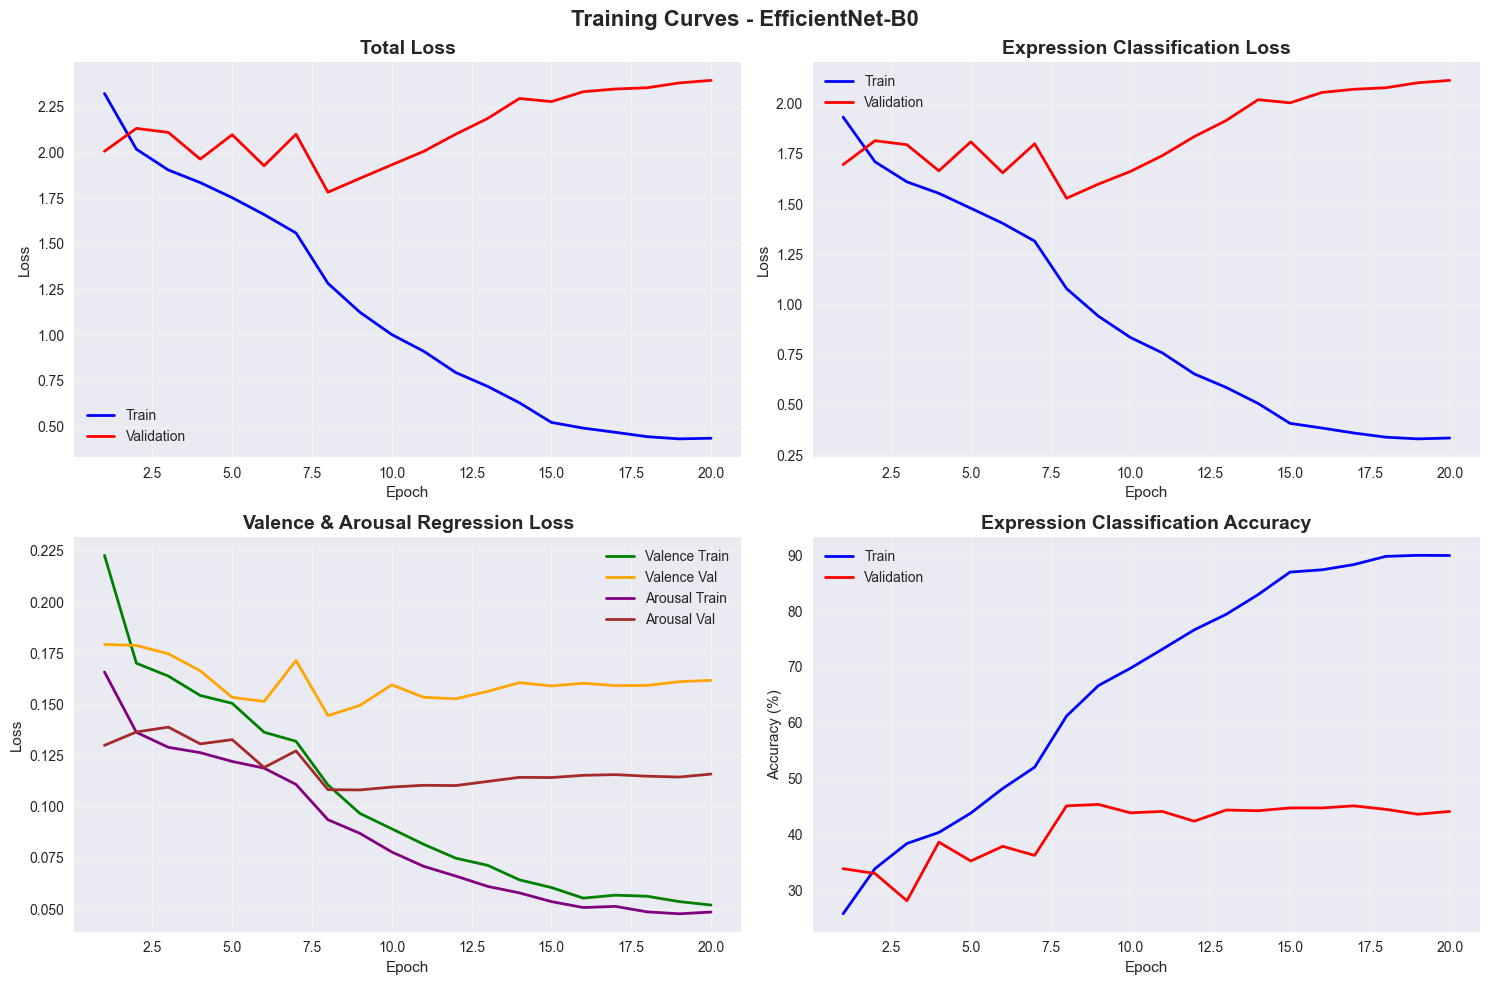

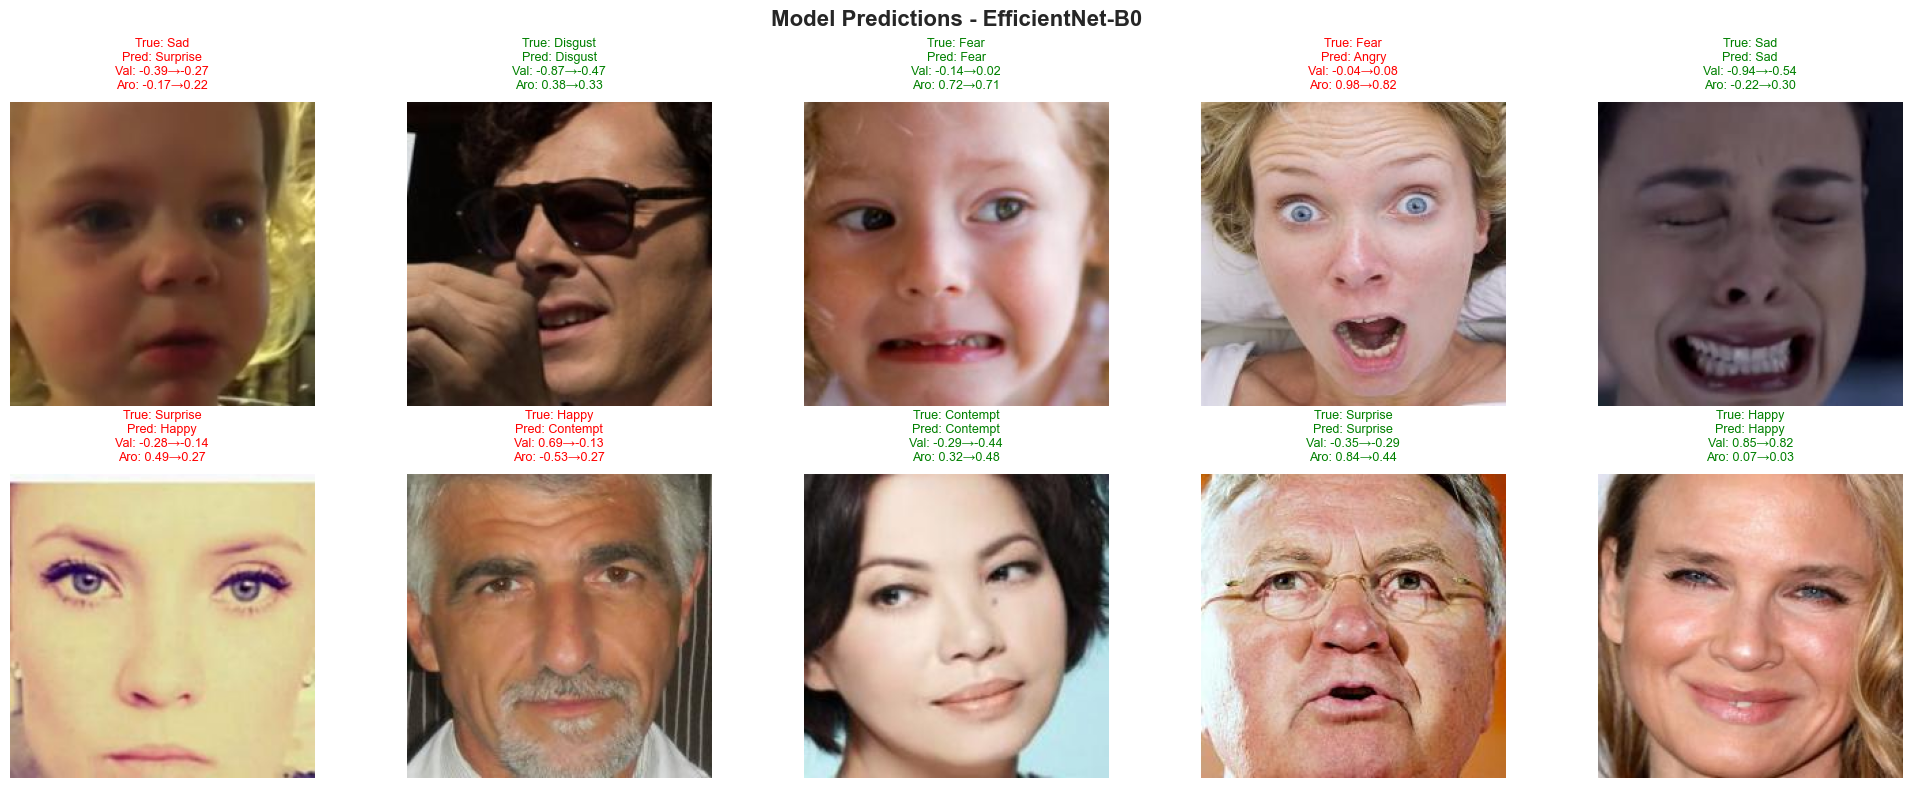

✅ EfficientNet-B0 training completed in 484.12 seconds

🎉 All models trained successfully!


In [ ]:
# Training both models
print(" Starting model training...")
print("="*60)

# Store results for comparison
model_results = {}
training_times = {}

# Train ResNet18
print("\n Training ResNet18...")
import time
start_time = time.time()

try:
    resnet_trainer = train_model('resnet18', train_loader, val_loader, device, num_epochs=NUM_EPOCHS)
    resnet_training_time = time.time() - start_time
    training_times['ResNet18'] = resnet_training_time
    
    # Evaluate ResNet18
    print("\n📊 Evaluating ResNet18...")
    resnet_results = evaluate_model(resnet_trainer, val_loader, device)
    model_results['ResNet18'] = resnet_results
    
    # Print results
    print_evaluation_results(resnet_results, 'ResNet18')
    
    # Plot training curves
    plot_training_curves(resnet_trainer, 'ResNet18')
    
    # Visualize predictions
    visualize_predictions(resnet_trainer, val_loader, device, num_samples=10, model_name='ResNet18')
    
    print(f" ResNet18 training completed in {resnet_training_time:.2f} seconds")
    
except Exception as e:
    print(f" Error training ResNet18: {e}")

# Train EfficientNet-B0
print("\n Training EfficientNet-B0...")
start_time = time.time()

try:
    efficientnet_trainer = train_model('efficientnet_b0', train_loader, val_loader, device, num_epochs=NUM_EPOCHS)
    efficientnet_training_time = time.time() - start_time
    training_times['EfficientNet-B0'] = efficientnet_training_time
    
    # Evaluate EfficientNet-B0
    print("\n📊 Evaluating EfficientNet-B0...")
    efficientnet_results = evaluate_model(efficientnet_trainer, val_loader, device)
    model_results['EfficientNet-B0'] = efficientnet_results
    
    # Print results
    print_evaluation_results(efficientnet_results, 'EfficientNet-B0')
    
    # Plot training curves
    plot_training_curves(efficientnet_trainer, 'EfficientNet-B0')
    
    # Visualize predictions
    visualize_predictions(efficientnet_trainer, val_loader, device, num_samples=10, model_name='EfficientNet-B0')
    
    print(f" EfficientNet-B0 training completed in {efficientnet_training_time:.2f} seconds")
    
except Exception as e:
    print(f" Error training EfficientNet-B0: {e}")

print("\n All models trained successfully!")


## 8. Model Comparison and Analysis


 Generating model comparison...


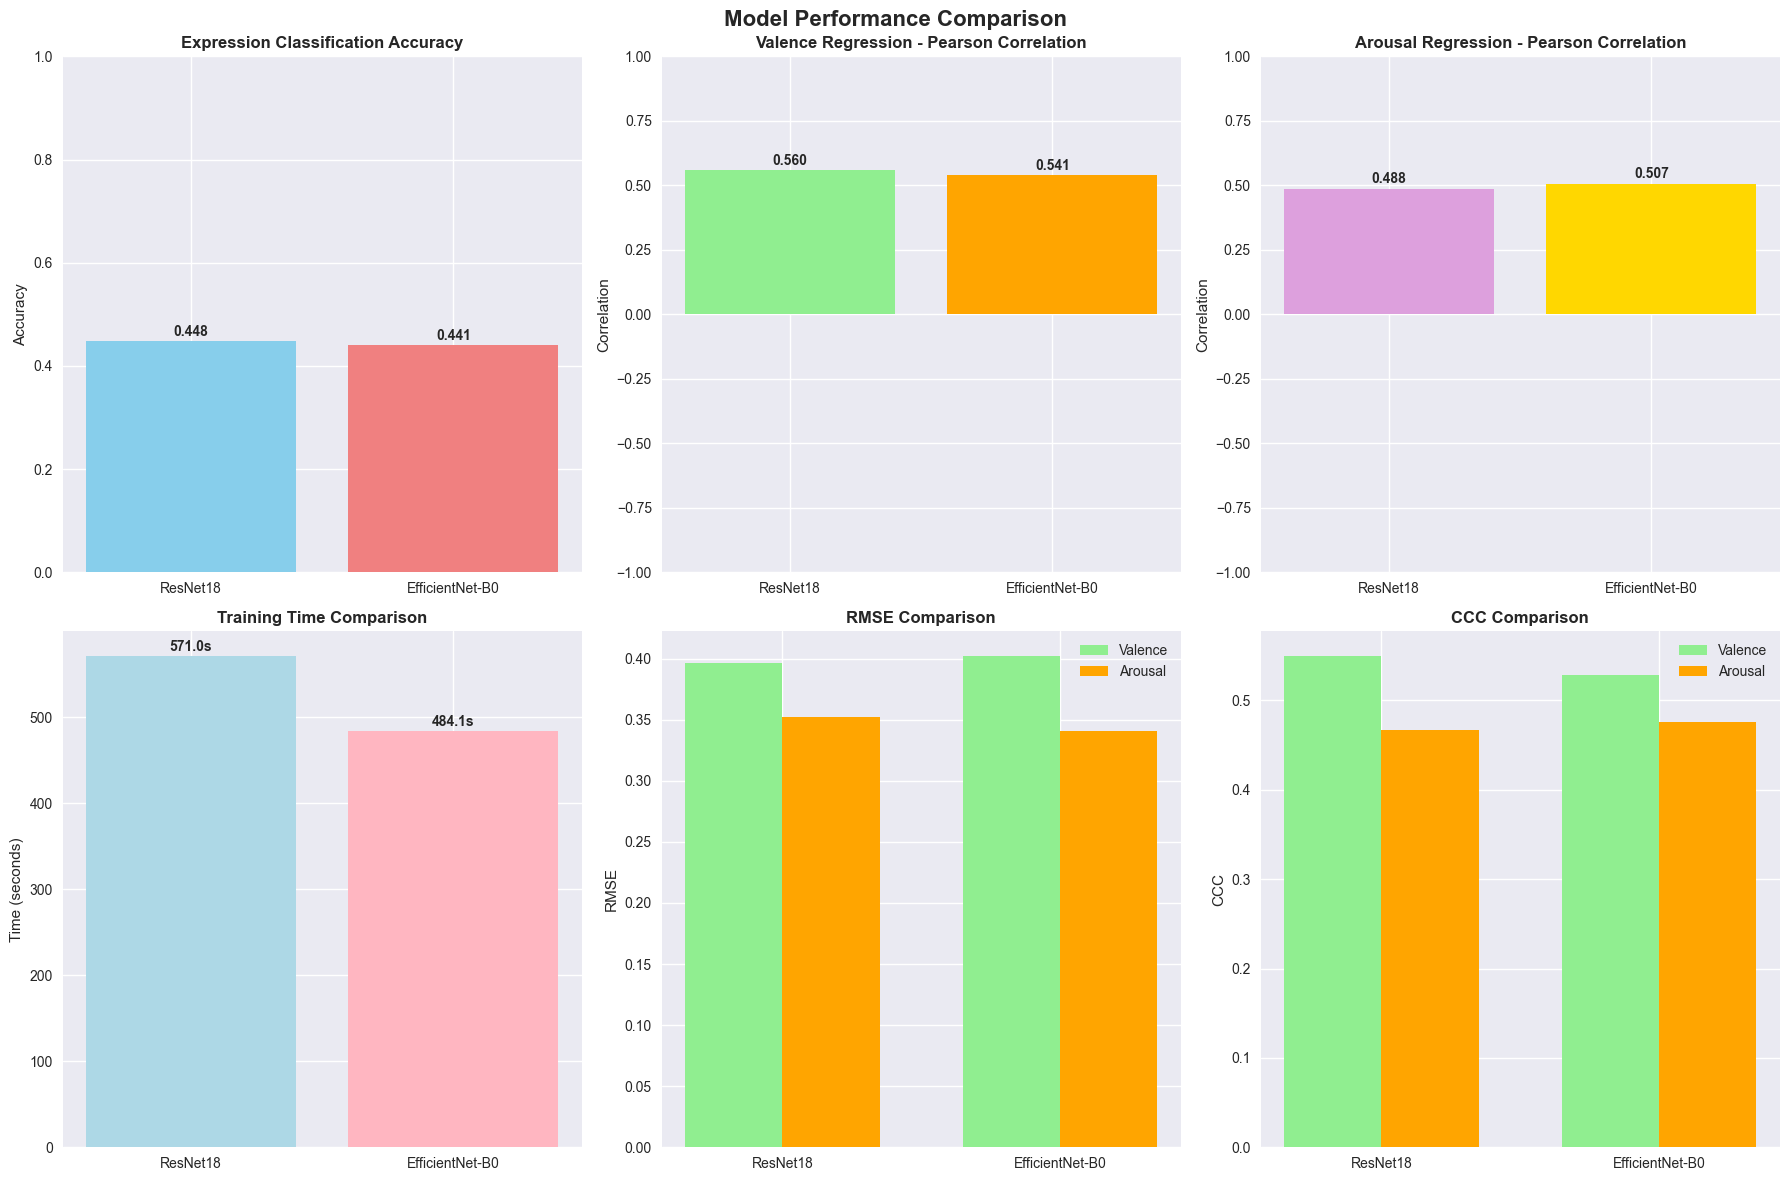


 COMPREHENSIVE MODEL COMPARISON REPORT

 DETAILED COMPARISON TABLE:
--------------------------------------------------------------------------------
          Model  Training Time (s)  Exp Accuracy  Exp F1-Score  Exp Cohen Kappa  Exp AUC (OvR)  Exp AUC-PR  Val RMSE  Val Pearson Corr  Val SAGR  Val CCC  Aro RMSE  Aro Pearson Corr  Aro SAGR  Aro CCC
       ResNet18           570.9526        0.4475        0.4489           0.3686         0.8220      0.4572    0.3965            0.5605    0.7675   0.5497    0.3521            0.4878    0.7812   0.4668
EfficientNet-B0           484.1164        0.4412        0.4414           0.3613         0.8173      0.4574    0.4022            0.5410    0.7600   0.5282    0.3405            0.5072    0.7825   0.4761

 BEST PERFORMING MODELS:
----------------------------------------
Expression Accuracy: ResNet18 (0.4475)
Valence Correlation: ResNet18 (0.5605)
Arousal Correlation: EfficientNet-B0 (0.5072)
Fastest Training: EfficientNet-B0 (484.12s)

 ANALYSIS S

In [11]:
def create_comparison_table(model_results, training_times):
    """
    Create a comprehensive comparison table of model results.
    
    Args:
        model_results: Dictionary containing evaluation results for each model
        training_times: Dictionary containing training times for each model
    
    Returns:
        pandas.DataFrame: Comparison table
    """
    comparison_data = []
    
    for model_name, results in model_results.items():
        row = {
            'Model': model_name,
            'Training Time (s)': training_times.get(model_name, 0),
            
            # Expression Classification Metrics
            'Exp Accuracy': results['expression']['accuracy'],
            'Exp F1-Score': results['expression']['f1_score'],
            'Exp Cohen Kappa': results['expression']['cohen_kappa'],
            'Exp AUC (OvR)': results['expression']['auc_ovr'],
            'Exp AUC-PR': results['expression']['auc_pr'],
            
            # Valence Regression Metrics
            'Val RMSE': results['valence']['rmse'],
            'Val Pearson Corr': results['valence']['pearson_corr'],
            'Val SAGR': results['valence']['sagr'],
            'Val CCC': results['valence']['ccc'],
            
            # Arousal Regression Metrics
            'Aro RMSE': results['arousal']['rmse'],
            'Aro Pearson Corr': results['arousal']['pearson_corr'],
            'Aro SAGR': results['arousal']['sagr'],
            'Aro CCC': results['arousal']['ccc'],
        }
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    return df

def plot_comparison_charts(model_results, training_times):
    """
    Create comparison charts for model performance.
    
    Args:
        model_results: Dictionary containing evaluation results for each model
        training_times: Dictionary containing training times for each model
    """
    models = list(model_results.keys())
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Expression Classification Accuracy
    accuracies = [model_results[model]['expression']['accuracy'] for model in models]
    axes[0, 0].bar(models, accuracies, color=['skyblue', 'lightcoral'])
    axes[0, 0].set_title('Expression Classification Accuracy', fontweight='bold')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    
    # 2. Valence Regression - Pearson Correlation
    val_corrs = [model_results[model]['valence']['pearson_corr'] for model in models]
    axes[0, 1].bar(models, val_corrs, color=['lightgreen', 'orange'])
    axes[0, 1].set_title('Valence Regression - Pearson Correlation', fontweight='bold')
    axes[0, 1].set_ylabel('Correlation')
    axes[0, 1].set_ylim(-1, 1)
    for i, v in enumerate(val_corrs):
        axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    
    # 3. Arousal Regression - Pearson Correlation
    aro_corrs = [model_results[model]['arousal']['pearson_corr'] for model in models]
    axes[0, 2].bar(models, aro_corrs, color=['plum', 'gold'])
    axes[0, 2].set_title('Arousal Regression - Pearson Correlation', fontweight='bold')
    axes[0, 2].set_ylabel('Correlation')
    axes[0, 2].set_ylim(-1, 1)
    for i, v in enumerate(aro_corrs):
        axes[0, 2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
    
    # 4. Training Time Comparison
    times = [training_times[model] for model in models]
    axes[1, 0].bar(models, times, color=['lightblue', 'lightpink'])
    axes[1, 0].set_title('Training Time Comparison', fontweight='bold')
    axes[1, 0].set_ylabel('Time (seconds)')
    for i, v in enumerate(times):
        axes[1, 0].text(i, v + max(times)*0.01, f'{v:.1f}s', ha='center', fontweight='bold')
    
    # 5. RMSE Comparison (Valence & Arousal)
    val_rmse = [model_results[model]['valence']['rmse'] for model in models]
    aro_rmse = [model_results[model]['arousal']['rmse'] for model in models]
    
    x = np.arange(len(models))
    width = 0.35
    
    axes[1, 1].bar(x - width/2, val_rmse, width, label='Valence', color='lightgreen')
    axes[1, 1].bar(x + width/2, aro_rmse, width, label='Arousal', color='orange')
    axes[1, 1].set_title('RMSE Comparison', fontweight='bold')
    axes[1, 1].set_ylabel('RMSE')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(models)
    axes[1, 1].legend()
    
    # 6. CCC Comparison (Valence & Arousal)
    val_ccc = [model_results[model]['valence']['ccc'] for model in models]
    aro_ccc = [model_results[model]['arousal']['ccc'] for model in models]
    
    axes[1, 2].bar(x - width/2, val_ccc, width, label='Valence', color='lightgreen')
    axes[1, 2].bar(x + width/2, aro_ccc, width, label='Arousal', color='orange')
    axes[1, 2].set_title('CCC Comparison', fontweight='bold')
    axes[1, 2].set_ylabel('CCC')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(models)
    axes[1, 2].legend()
    
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def generate_summary_report(model_results, training_times):
    """
    Generate a comprehensive summary report.
    
    Args:
        model_results: Dictionary containing evaluation results for each model
        training_times: Dictionary containing training times for each model
    """
    print("\n" + "="*80)
    print(" COMPREHENSIVE MODEL COMPARISON REPORT")
    print("="*80)
    
    # Create comparison table
    comparison_df = create_comparison_table(model_results, training_times)
    
    print("\n DETAILED COMPARISON TABLE:")
    print("-" * 80)
    print(comparison_df.round(4).to_string(index=False))
    
    # Find best performing model for each metric
    print("\n BEST PERFORMING MODELS:")
    print("-" * 40)
    
    # Expression Classification
    best_acc_model = comparison_df.loc[comparison_df['Exp Accuracy'].idxmax(), 'Model']
    best_acc_score = comparison_df['Exp Accuracy'].max()
    print(f"Expression Accuracy: {best_acc_model} ({best_acc_score:.4f})")
    
    # Valence Regression
    best_val_corr_model = comparison_df.loc[comparison_df['Val Pearson Corr'].idxmax(), 'Model']
    best_val_corr_score = comparison_df['Val Pearson Corr'].max()
    print(f"Valence Correlation: {best_val_corr_model} ({best_val_corr_score:.4f})")
    
    # Arousal Regression
    best_aro_corr_model = comparison_df.loc[comparison_df['Aro Pearson Corr'].idxmax(), 'Model']
    best_aro_corr_score = comparison_df['Aro Pearson Corr'].max()
    print(f"Arousal Correlation: {best_aro_corr_model} ({best_aro_corr_score:.4f})")
    
    # Training Time
    fastest_model = comparison_df.loc[comparison_df['Training Time (s)'].idxmin(), 'Model']
    fastest_time = comparison_df['Training Time (s)'].min()
    print(f"Fastest Training: {fastest_model} ({fastest_time:.2f}s)")
    
    # Overall Analysis
    print("\n ANALYSIS SUMMARY:")
    print("-" * 40)
    
    # Calculate average performance
    avg_acc = comparison_df['Exp Accuracy'].mean()
    avg_val_corr = comparison_df['Val Pearson Corr'].mean()
    avg_aro_corr = comparison_df['Aro Pearson Corr'].mean()
    
    print(f"Average Expression Accuracy: {avg_acc:.4f}")
    print(f"Average Valence Correlation: {avg_val_corr:.4f}")
    print(f"Average Arousal Correlation: {avg_aro_corr:.4f}")
    
    # Performance insights
    print("\n KEY INSIGHTS:")
    print("-" * 40)
    
    if abs(comparison_df['Exp Accuracy'].iloc[0] - comparison_df['Exp Accuracy'].iloc[1]) < 0.05:
        print("• Expression classification performance is similar between models")
    else:
        better_exp = best_acc_model
        print(f"• {better_exp} shows better expression classification performance")
    
    if abs(comparison_df['Val Pearson Corr'].iloc[0] - comparison_df['Val Pearson Corr'].iloc[1]) < 0.1:
        print("• Valence regression performance is comparable between models")
    else:
        better_val = best_val_corr_model
        print(f"• {better_val} shows better valence regression performance")
    
    if abs(comparison_df['Aro Pearson Corr'].iloc[0] - comparison_df['Aro Pearson Corr'].iloc[1]) < 0.1:
        print("• Arousal regression performance is comparable between models")
    else:
        better_aro = best_aro_corr_model
        print(f"• {better_aro} shows better arousal regression performance")
    
    # Training efficiency
    time_ratio = comparison_df['Training Time (s)'].max() / comparison_df['Training Time (s)'].min()
    if time_ratio > 1.5:
        print(f"• Significant training time difference (ratio: {time_ratio:.2f}x)")
    else:
        print("• Training times are similar between models")
    
    return comparison_df

# Generate comparison if models were trained
if 'model_results' in locals() and len(model_results) > 0:
    print(" Generating model comparison...")
    
    # Create comparison table
    comparison_df = create_comparison_table(model_results, training_times)
    
    # Plot comparison charts
    plot_comparison_charts(model_results, training_times)
    
    # Generate summary report
    summary_df = generate_summary_report(model_results, training_times)
    
else:
    print("⚠️  No model results available for comparison.")
    print("Please run the training section first.")
